In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# 1. Load the engineered dataset
print("Step 1: Loading 'Model1_Demand_Data.csv'...")
df = pd.read_csv('Model1_Demand_Data.csv')
print(f"Dataset loaded. Total shifts for training: {len(df)}")

Step 1: Loading 'Model1_Demand_Data.csv'...
Dataset loaded. Total shifts for training: 1623


In [20]:
# 2. Define Features and Target
print("\nStep 2: Defining features and target variable...")
# We use location, time, and the previous shift's performance to predict demand
features = ['store_location', 'shift', 'month', 'day_of_week', 'is_weekend', 'prev_cups']
target = 'total_cups'

X = df[features]
y = df[target]
print(f"Features: {features}")
print(f"Target: {target}")


Step 2: Defining features and target variable...
Features: ['store_location', 'shift', 'month', 'day_of_week', 'is_weekend', 'prev_cups']
Target: total_cups


In [21]:
# 3. Preprocessing and Model Pipeline
print("\nStep 3: Setting up preprocessing (One-Hot Encoding) and Random Forest...")
categorical_features = ['store_location', 'shift', 'day_of_week']

# Convert text categories into numeric format for the machine
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Create a pipeline that combines preprocessing and the regressor
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])


Step 3: Setting up preprocessing (One-Hot Encoding) and Random Forest...


In [22]:
# 4. Split the Data
print("\nStep 4: Splitting data into Training (80%) and Testing (20%) sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")


Step 4: Splitting data into Training (80%) and Testing (20%) sets...
Training set size: 1298
Testing set size: 325


In [23]:
# 5. Train the Model
print("\nStep 5: Training the Random Forest model (this may take a moment)...")
model_pipeline.fit(X_train, y_train)
print("Training complete.")


Step 5: Training the Random Forest model (this may take a moment)...
Training complete.


In [24]:
# 6. Evaluation
print("\nStep 6: Evaluating model performance on unseen data...")
y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print(f"MODEL 1 RESULTS:")
print(f"Mean Absolute Error: {mae:.2f} cups")
print(f"R-Squared (Accuracy): {r2:.4f}")
print("-" * 30)


Step 6: Evaluating model performance on unseen data...
------------------------------
MODEL 1 RESULTS:
Mean Absolute Error: 31.11 cups
R-Squared (Accuracy): 0.7528
------------------------------


In [25]:
# 6. Generate Predictions for Metrics
y_pred = model_pipeline.predict(X_test)


Visualizing Metric 1: Actual vs. Predicted...


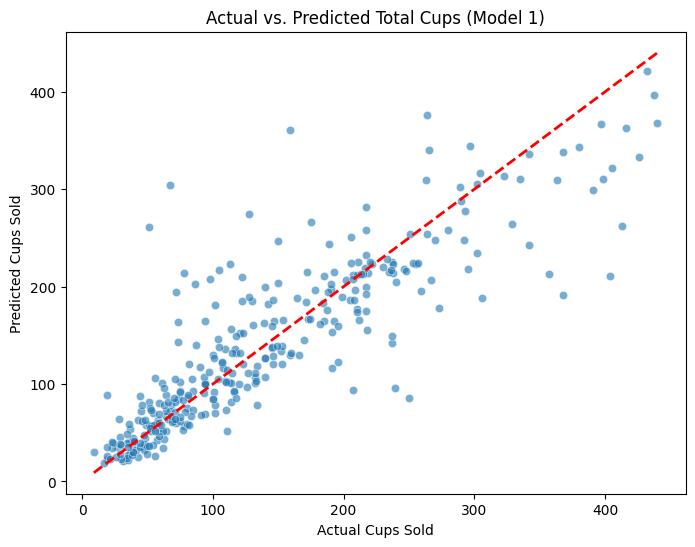


Visualizing Metric 2: Residual Analysis (Error Distribution)...


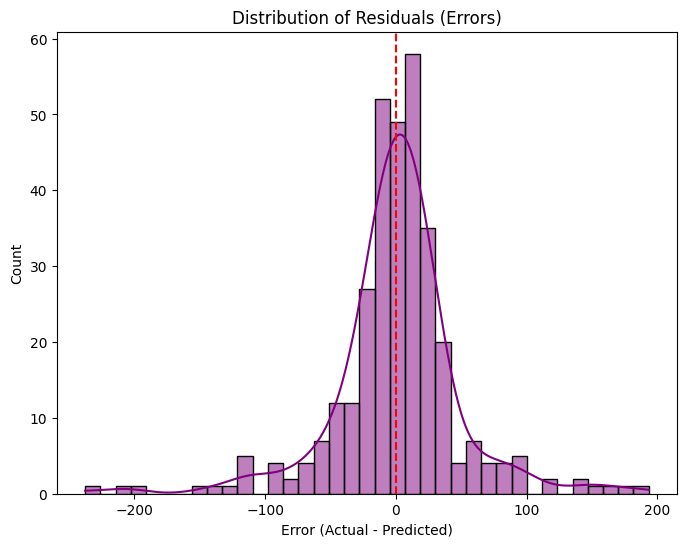


FINAL REGRESSION METRICS
Mean Absolute Error (MAE):  31.11 cups
Root Mean Squared Error (RMSE): 48.66 cups
R-Squared (Accuracy):       0.7528


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- VISUAL METRIC 1: ACTUAL VS PREDICTED ---
print("\nVisualizing Metric 1: Actual vs. Predicted...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
# This draws the "perfect prediction" line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Total Cups (Model 1)')
plt.xlabel('Actual Cups Sold')
plt.ylabel('Predicted Cups Sold')
plt.show()

# --- VISUAL METRIC 2: RESIDUALS DISTRIBUTION ---
print("\nVisualizing Metric 2: Residual Analysis (Error Distribution)...")
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Error (Actual - Predicted)')
plt.show()

# --- FINAL METRIC PRINTOUT ---
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n" + "="*30)
print("FINAL REGRESSION METRICS")
print("="*30)
print(f"Mean Absolute Error (MAE):  {mae:.2f} cups")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} cups")
print(f"R-Squared (Accuracy):       {r2:.4f}")
print("="*30)

In [27]:
# 8. Export
joblib.dump(model_pipeline, 'model1_demand_forecast.pkl')
print("\nFinal Model Exported as 'model1_demand_forecast.pkl'")


Final Model Exported as 'model1_demand_forecast.pkl'
